# Week 3 Milestone 1 — VAE on 2D Synthetic Data

This notebook builds a **Variational Autoencoder (VAE)** for simple 2D datasets: **blobs**, **circles**, and **moons**.

The goal is not just to copy code. The goal is to understand the engineering decisions:

- Why start with a linear VAE?
- How do we choose the number of hidden layers?
- Which activation function should we use: ReLU, Tanh, LeakyReLU, or none?
- Why choose a 2D blobs dataset first?
- What alternatives should we reject and why?
- How does the training loop actually work?
- How do we know whether the model is working?

The assignment asks for a working `LinearVAE`, decreasing loss, reconstruction plot, latent space plot, and generated samples. This notebook includes all of them.

## 1. Big Picture

A **generative model** learns a data pattern and creates new examples.

For this assignment, every input is a 2D point:

$$ x = [x_1, x_2] $$

A VAE does this:

$$ x \rightarrow \text{Encoder} \rightarrow (\mu, \log\sigma^2) \rightarrow z \rightarrow \text{Decoder} \rightarrow \hat{x} $$

The encoder does not produce one exact code. It produces a **distribution** using `mu` and `logvar`. The decoder reconstructs the point from a sampled latent code `z`.

A regular autoencoder may reconstruct well, but random latent points can decode into garbage. A VAE forces the latent space to stay close to a normal distribution, so random sampling becomes meaningful.

## 2. Engineering Decision: Which Dataset First?

| Dataset | Shape | Difficulty | What it tests |
|---|---|---:|---|
| Blobs | Separate clusters | Easy | Can the VAE model disconnected groups? |
| Circles | Ring shape | Medium | Can the VAE learn curved structure? |
| Moons | Two interleaving curves | Harder | Can the VAE model non-linear, multi-mode structure? |

### Decision

Start with **2D blobs** for debugging, then move to **moons**.

Blobs are easy to inspect. If the model cannot reconstruct blobs, the problem is likely in the code, loss, training loop, or hyperparameters.

### Rejected alternative: Start directly with moons

Rejected because moons are harder. If results are bad, we will not know whether the code is wrong or whether the model is simply too linear.

In [ ]:
%matplotlib inline

import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Dataset Function

We standardize the data using `StandardScaler` so both coordinates are centered near 0 and have similar scale. This usually makes neural network training more stable.

In [ ]:
def make_2d_dataset(kind="blobs", n_samples=3000, noise=0.05, batch_size=256):
    if kind == "blobs":
        X, y = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.55, random_state=SEED)
    elif kind == "circles":
        X, y = make_circles(n_samples=n_samples, noise=noise, factor=0.5, random_state=SEED)
    elif kind == "moons":
        X, y = make_moons(n_samples=n_samples, noise=noise, random_state=SEED)
    else:
        raise ValueError("kind must be one of: blobs, circles, moons")

    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X_tensor = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return X_tensor, y, train_loader

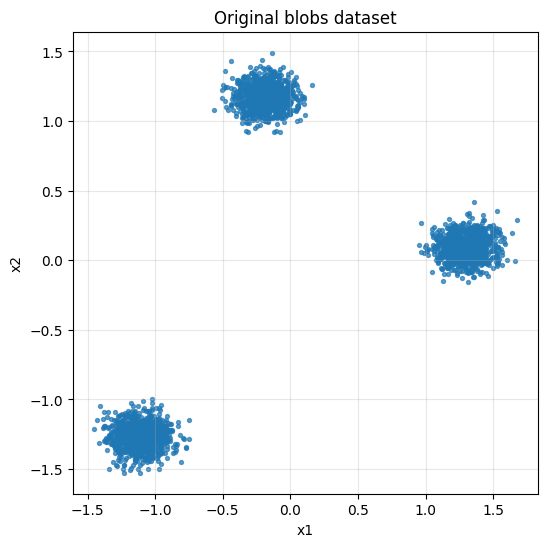

In [ ]:
DATASET_KIND = "blobs"  # Try: "blobs", "circles", "moons"
X_data, y_labels, train_loader = make_2d_dataset(kind=DATASET_KIND, batch_size=256)

plt.figure(figsize=(6, 6))
plt.scatter(X_data[:, 0], X_data[:, 1], s=8, alpha=0.7)
plt.title(f"Original {DATASET_KIND} dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Linear VAE vs Non-Linear VAE

### Linear VAE

A linear VAE uses only linear layers:

$$ y = Wx + b $$

No hidden layers. No activation functions.

Advantages: simple, easy to debug, fast, good as a baseline.

Limitations: it cannot bend space well, so it struggles with moons and circles.

### Non-linear VAE

A non-linear VAE uses hidden layers and activation functions:

$$ x \rightarrow \text{Linear} \rightarrow \text{Activation} \rightarrow \text{Linear} \rightarrow \mu, \log\sigma^2 $$

This can learn curved shapes better.

### Decision

Implement both:

1. `LinearVAE` for the assignment baseline.
2. `MLPVAE` for experiments with hidden layers and activations.

In [ ]:
class LinearVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim * 2)
        self.decoder = nn.Linear(latent_dim, input_dim)

    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

## 5. How to Choose Hidden Layers

There is no magic number. Choose based on dataset complexity.

| Dataset | Suggested model |
|---|---|
| Blobs | Linear VAE or 1 hidden layer |
| Circles | 1 to 2 hidden layers |
| Moons | 2 hidden layers often works better |

For this assignment, a good non-linear starting point is:

```python
hidden_dims = [32, 32]
```

Rejected alternative: 5 to 10 hidden layers. This is overkill for 2D points, harder to debug, and not necessary.

## 6. Activation Functions

Activation functions make the network non-linear. Without them, many linear layers are still just one big linear transformation:

$$ \text{Linear}(\text{Linear}(x)) = \text{another Linear function} $$

| Activation | Good for | Problem |
|---|---|---|
| ReLU | Simple default | Can create dead neurons |
| LeakyReLU | Safer ReLU | Slightly more complex |
| Tanh | Smooth outputs | Can saturate and slow training |
| Sigmoid | Rarely good for hidden layers | Strong saturation |
| None | Linear baseline | Cannot learn curved shapes well |

Decision: use `ReLU` first, try `LeakyReLU` if ReLU is weak, and try `Tanh` as an experiment. Reject sigmoid as a main hidden activation.

In [ ]:
def get_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.01)
    if name == "tanh":
        return nn.Tanh()
    if name == "none":
        return nn.Identity()
    raise ValueError("activation must be: relu, leakyrelu, tanh, none")


class MLPVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2, hidden_dims=[64, 64], activation="tanh"):
        super().__init__()

        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            encoder_layers.append(get_activation(activation))
            prev_dim = hidden_dim

        self.encoder_body = nn.Sequential(*encoder_layers)
        self.encoder_out = nn.Linear(prev_dim, latent_dim * 2)

        decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            decoder_layers.append(get_activation(activation))
            prev_dim = hidden_dim

        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder_body(x)
        h = self.encoder_out(h)
        mu, logvar = h.chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

## 7. Loss Function

The loss has two terms:

### Reconstruction loss

$$ L_{recon} = \|x - \hat{x}\|^2 $$

This checks whether the reconstructed point is close to the input point.

### KL divergence

$$ D_{KL} = -\frac{1}{2}\sum(1 + \log\sigma^2 - \mu^2 - \sigma^2) $$

This pushes the latent distribution toward standard normal:

$$ N(0, I) $$

We use:

$$ L = L_{recon} + \beta D_{KL} $$

`beta` controls the strength of KL regularization.

| beta | Effect |
|---:|---|
| 0 | More like a normal autoencoder; poor generation |
| 0.1 | Weaker KL; often clearer reconstruction |
| 0.5 | Balanced for toy data |
| 1.0 | Standard VAE |
| 5+ | KL may dominate and collapse latent space |

Decision: start with `beta = 0.5` for moons or blobs.

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=0.1):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

## 8. Training Step Explained

For every mini-batch:

1. Take batch `x`.
2. Encode it into `mu` and `logvar`.
3. Sample latent code `z` using the reparameterization trick.
4. Decode `z` into `recon_x`.
5. Compute reconstruction loss and KL loss.
6. Clear old gradients with `optimizer.zero_grad()`.
7. Compute new gradients with `loss.backward()`.
8. Update weights with `optimizer.step()`.

Rejected alternative: train on all 3000 points at once. Mini-batches are more standard, scalable, and closer to real ML workflows.

In [ ]:
def train_vae(model, train_loader, epochs=1000, lr=5e-3, beta=0.1, print_every=50):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"total_loss": [], "recon_loss": [], "kl_loss": []}
    num_points = len(train_loader.dataset)

    for epoch in range(epochs):
        model.train()
        total_loss_sum = recon_loss_sum = kl_loss_sum = 0.0

        for batch in train_loader:
            x = batch[0].to(device)
            recon_x, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss_sum += loss.item()
            recon_loss_sum += recon_loss.item()
            kl_loss_sum += kl_loss.item()

        history["total_loss"].append(total_loss_sum / num_points)
        history["recon_loss"].append(recon_loss_sum / num_points)
        history["kl_loss"].append(kl_loss_sum / num_points)

        if epoch % print_every == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d} | Total: {history['total_loss'][-1]:.4f} | Recon: {history['recon_loss'][-1]:.4f} | KL: {history['kl_loss'][-1]:.4f}")

    return history

In [ ]:
def plot_loss_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["total_loss"], label="Total loss")
    plt.plot(history["recon_loss"], label="Reconstruction loss")
    plt.plot(history["kl_loss"], label="KL loss")
    plt.title("Training Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss per point")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_original(data, title="Original Dataset"):
    data_cpu = data.detach().cpu()
    plt.figure(figsize=(6, 6))
    plt.scatter(data_cpu[:, 0], data_cpu[:, 1], s=8, alpha=0.7)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_reconstructions(model, data, n=1000):
    model.eval()
    data = data[:n].to(device)
    with torch.no_grad():
        recon, _, _ = model(data)
    data_cpu = data.cpu()
    recon_cpu = recon.cpu()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(data_cpu[:, 0], data_cpu[:, 1], s=8, alpha=0.7)
    plt.title("Original Data")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(recon_cpu[:, 0], recon_cpu[:, 1], s=8, alpha=0.7)
    plt.title("Reconstructed Data")
    plt.xlabel("x1 reconstructed")
    plt.ylabel("x2 reconstructed")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_original_vs_reconstruction(model, data, n=1000):
    model.eval()
    data = data[:n].to(device)
    with torch.no_grad():
        recon, _, _ = model(data)
    data_cpu = data.cpu()
    recon_cpu = recon.cpu()

    plt.figure(figsize=(6, 6))
    plt.scatter(data_cpu[:, 0], data_cpu[:, 1], s=8, alpha=0.45, label="Original")
    plt.scatter(recon_cpu[:, 0], recon_cpu[:, 1], s=8, alpha=0.45, label="Reconstructed")
    plt.title("Original vs Reconstructed")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_latent_space(model, data):
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        mu, logvar = model.encode(data)
    mu_cpu = mu.cpu()

    plt.figure(figsize=(6, 6))
    plt.scatter(mu_cpu[:, 0], mu_cpu[:, 1], s=8, alpha=0.6)
    plt.xlabel("Latent dim 1")
    plt.ylabel("Latent dim 2")
    plt.title("Latent Space: Encoder Means")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_generated(model, n=1000, latent_dim=2):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, latent_dim).to(device)
        samples = model.decode(z)
    samples_cpu = samples.cpu()

    plt.figure(figsize=(6, 6))
    plt.scatter(samples_cpu[:, 0], samples_cpu[:, 1], s=8, alpha=0.6)
    plt.title("Generated Samples from Random Noise")
    plt.xlabel("x1 generated")
    plt.ylabel("x2 generated")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_interpolation(model, data, idx1=0, idx2=50, steps=20):
    model.eval()
    x1 = data[idx1:idx1+1].to(device)
    x2 = data[idx2:idx2+1].to(device)
    with torch.no_grad():
        mu1, _ = model.encode(x1)
        mu2, _ = model.encode(x2)
        alphas = torch.linspace(0, 1, steps).to(device).view(-1, 1)
        z_path = (1 - alphas) * mu1 + alphas * mu2
        decoded_path = model.decode(z_path).cpu()

    data_cpu = data.cpu()
    plt.figure(figsize=(6, 6))
    plt.scatter(data_cpu[:, 0], data_cpu[:, 1], s=5, alpha=0.25, label="Original data")
    plt.plot(decoded_path[:, 0], decoded_path[:, 1], marker="o", label="Decoded interpolation path")
    plt.title("Latent Interpolation Decoded into Data Space")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 9. Experiment A: Train the Required LinearVAE

This is the assignment baseline.

Expected behavior:

- On blobs: should reconstruct reasonably.
- On moons: may reconstruct a blurred or compressed version.
- Generated samples may look like a smooth cloud instead of perfect moons.

That is a limitation of the linear architecture, not necessarily a code error.

In [ ]:
DATASET_KIND = "blobs"      # Try: "blobs", "circles", "moons"
LATENT_DIM = 2
BATCH_SIZE = 256
EPOCHS = 1000
LR = 5e-3
BETA = 0.1

X_data, y_labels, train_loader = make_2d_dataset(
    kind=DATASET_KIND,
    n_samples=3000,
    noise=0.05,
    batch_size=BATCH_SIZE
)

linear_vae = LinearVAE(input_dim=2, latent_dim=LATENT_DIM)
linear_history = train_vae(linear_vae, train_loader, epochs=EPOCHS, lr=LR, beta=BETA, print_every=25)

Epoch   0 | Total: 2.4785 | Recon: 2.3626 | KL: 1.1587
Epoch  25 | Total: 0.7881 | Recon: 0.5693 | KL: 2.1880
Epoch  50 | Total: 0.4713 | Recon: 0.1934 | KL: 2.7782
Epoch  75 | Total: 0.4258 | Recon: 0.1519 | KL: 2.7390
Epoch 100 | Total: 0.4068 | Recon: 0.1305 | KL: 2.7628
Epoch 125 | Total: 0.3972 | Recon: 0.1150 | KL: 2.8217
Epoch 150 | Total: 0.3901 | Recon: 0.1042 | KL: 2.8593
Epoch 175 | Total: 0.3914 | Recon: 0.1015 | KL: 2.8992
Epoch 200 | Total: 0.3931 | Recon: 0.1012 | KL: 2.9185
Epoch 225 | Total: 0.3887 | Recon: 0.0981 | KL: 2.9064
Epoch 250 | Total: 0.3884 | Recon: 0.0976 | KL: 2.9076
Epoch 275 | Total: 0.3879 | Recon: 0.0978 | KL: 2.9012
Epoch 300 | Total: 0.3869 | Recon: 0.0985 | KL: 2.8840
Epoch 325 | Total: 0.3870 | Recon: 0.0967 | KL: 2.9031
Epoch 350 | Total: 0.3871 | Recon: 0.0971 | KL: 2.9000
Epoch 375 | Total: 0.3925 | Recon: 0.1030 | KL: 2.8947
Epoch 400 | Total: 0.3892 | Recon: 0.0989 | KL: 2.9029
Epoch 425 | Total: 0.3883 | Recon: 0.0999 | KL: 2.8839
Epoch 450 

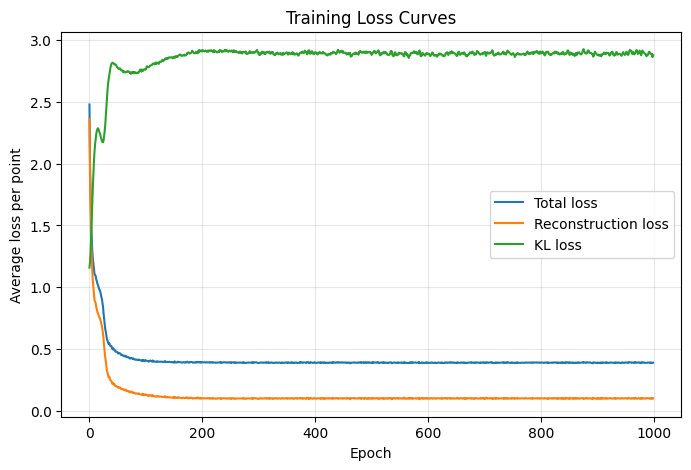

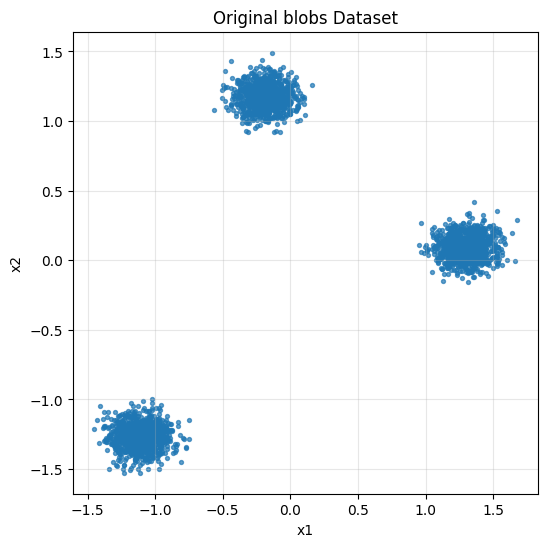

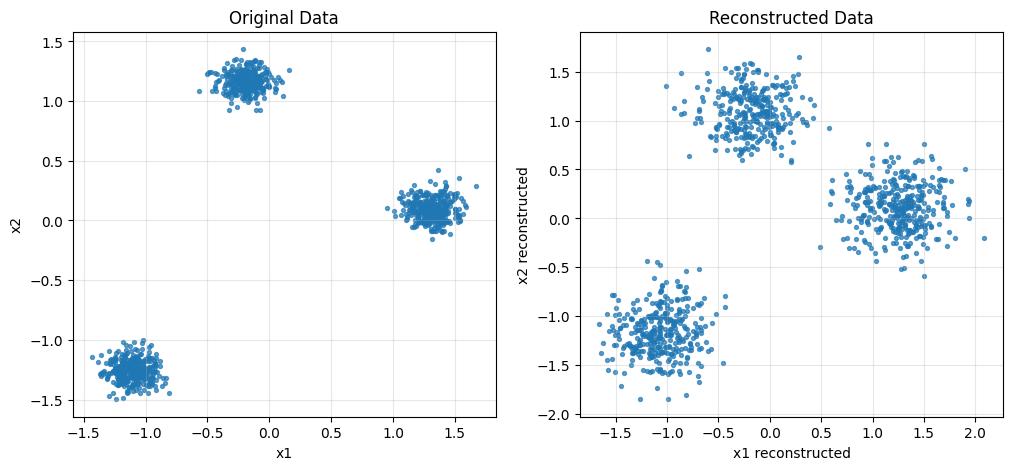

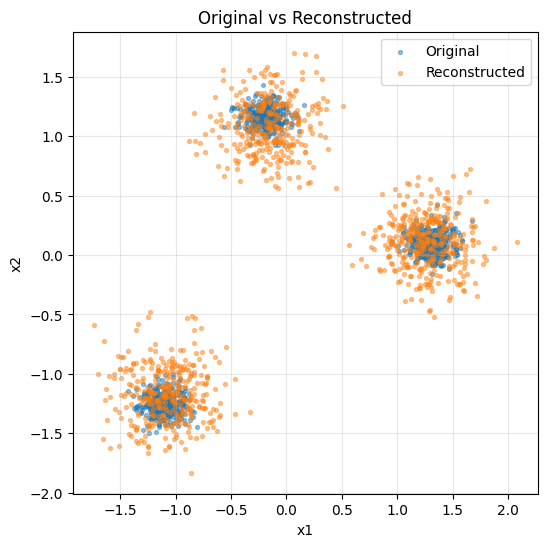

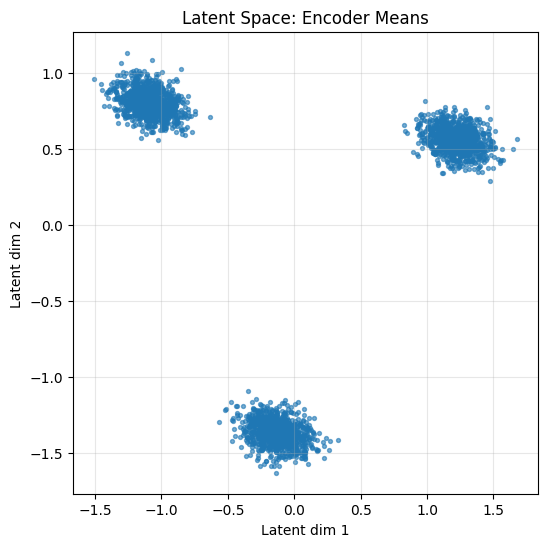

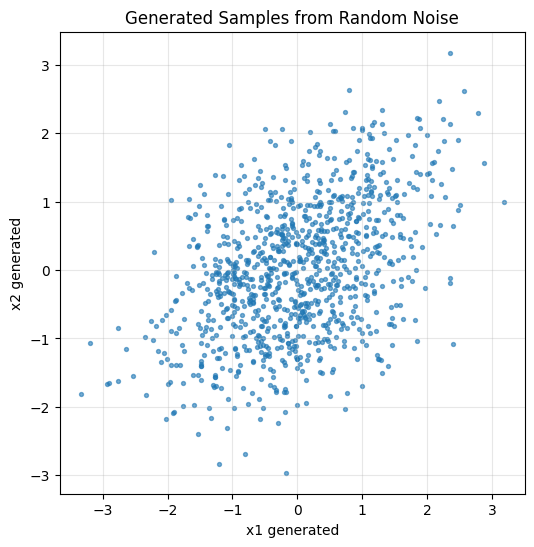

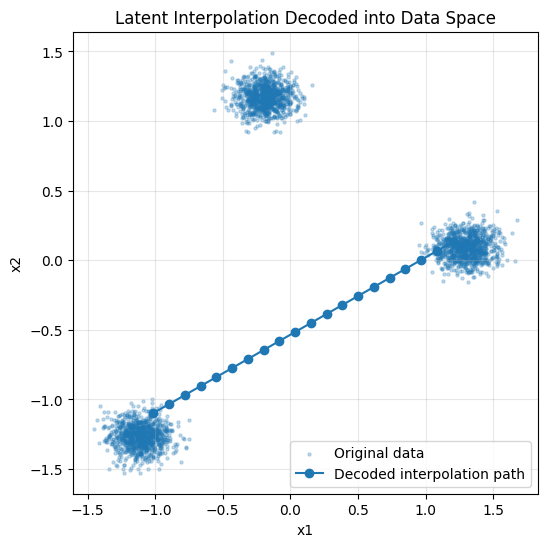

In [ ]:
plot_loss_history(linear_history)
plot_original(X_data, title=f"Original {DATASET_KIND} Dataset")
plot_reconstructions(linear_vae, X_data, n=1000)
plot_original_vs_reconstruction(linear_vae, X_data, n=1000)
plot_latent_space(linear_vae, X_data)
plot_generated(linear_vae, n=1000, latent_dim=LATENT_DIM)
plot_interpolation(linear_vae, X_data, idx1=0, idx2=100, steps=20)

## 10. Experiment B: Try a Non-Linear VAE

Suggested settings:

```python
hidden_dims = [32, 32]
activation = "relu"
```

Why this is reasonable:

- The dataset is only 2D, so huge networks are unnecessary.
- Two hidden layers can learn curved structures better than a linear model.
- ReLU is a simple default activation.

Try changing `activation` to `tanh` or `leakyrelu`, and `hidden_dims` to `[16]` or `[64, 64]`.

In [ ]:
mlp_vae = MLPVAE(input_dim=2, latent_dim=LATENT_DIM, hidden_dims=[64, 64], activation="relu")
mlp_history = train_vae(mlp_vae, train_loader, epochs=EPOCHS, lr=LR, beta=BETA, print_every=50)

Epoch   0 | Total: 1.5269 | Recon: 1.4547 | KL: 0.7220
Epoch  50 | Total: 0.2179 | Recon: 0.0389 | KL: 1.7903
Epoch 100 | Total: 0.2150 | Recon: 0.0391 | KL: 1.7590
Epoch 150 | Total: 0.2278 | Recon: 0.0336 | KL: 1.9413
Epoch 200 | Total: 0.2134 | Recon: 0.0339 | KL: 1.7948
Epoch 250 | Total: 0.2242 | Recon: 0.0500 | KL: 1.7423
Epoch 300 | Total: 0.2210 | Recon: 0.0398 | KL: 1.8120
Epoch 350 | Total: 0.2226 | Recon: 0.0400 | KL: 1.8259
Epoch 400 | Total: 0.2092 | Recon: 0.0317 | KL: 1.7751
Epoch 450 | Total: 0.2208 | Recon: 0.0360 | KL: 1.8477
Epoch 500 | Total: 0.2163 | Recon: 0.0394 | KL: 1.7689
Epoch 550 | Total: 0.2214 | Recon: 0.0444 | KL: 1.7693
Epoch 600 | Total: 0.2183 | Recon: 0.0412 | KL: 1.7711
Epoch 650 | Total: 0.2167 | Recon: 0.0463 | KL: 1.7035
Epoch 700 | Total: 0.2141 | Recon: 0.0400 | KL: 1.7418
Epoch 750 | Total: 0.2208 | Recon: 0.0358 | KL: 1.8501
Epoch 800 | Total: 0.2123 | Recon: 0.0361 | KL: 1.7624
Epoch 850 | Total: 0.2109 | Recon: 0.0287 | KL: 1.8213
Epoch 900 

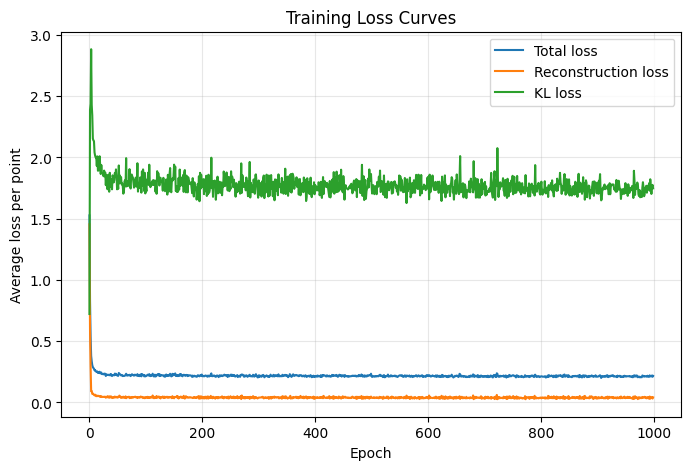

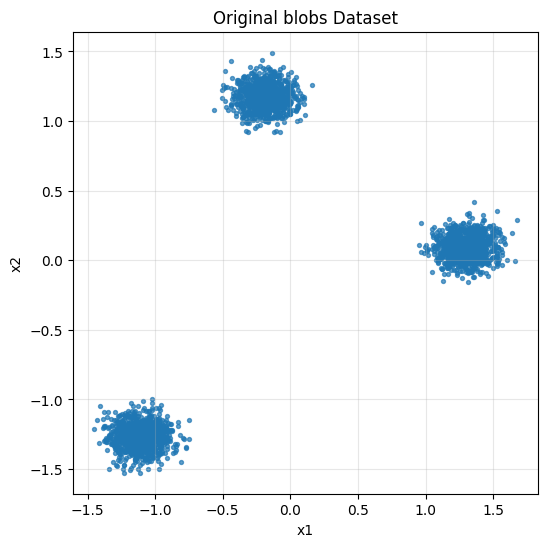

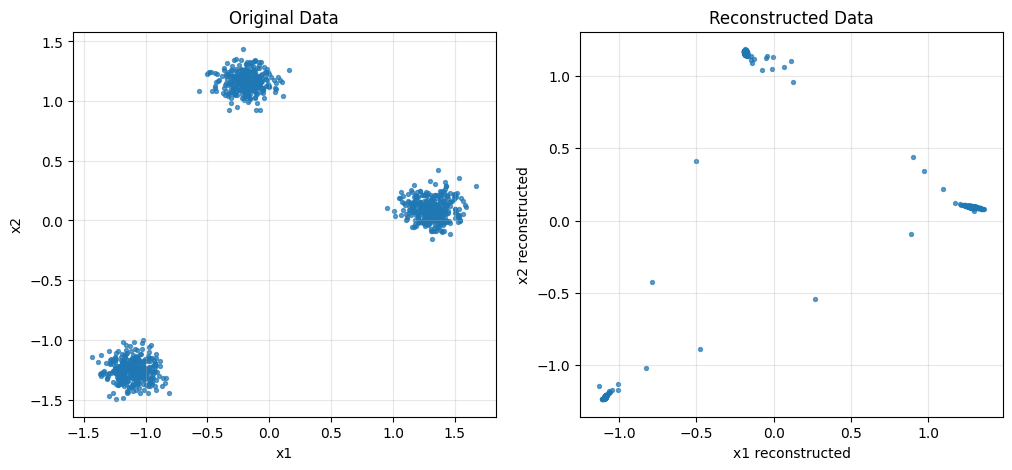

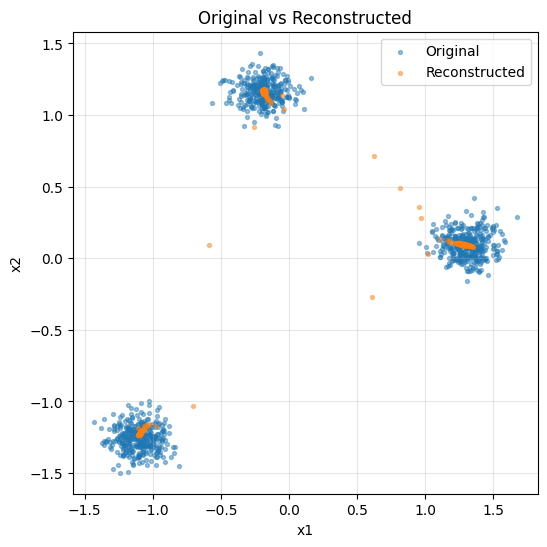

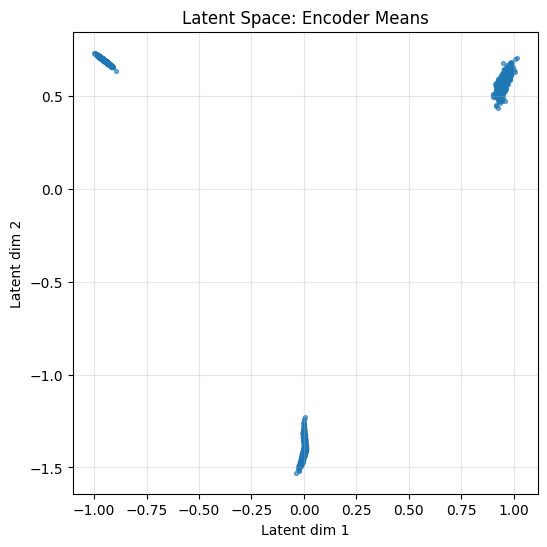

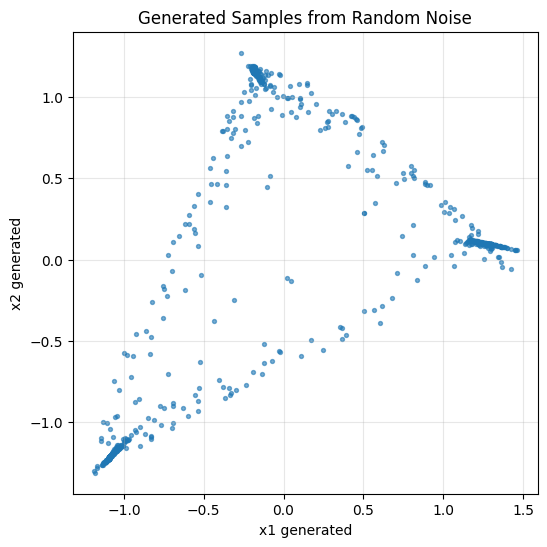

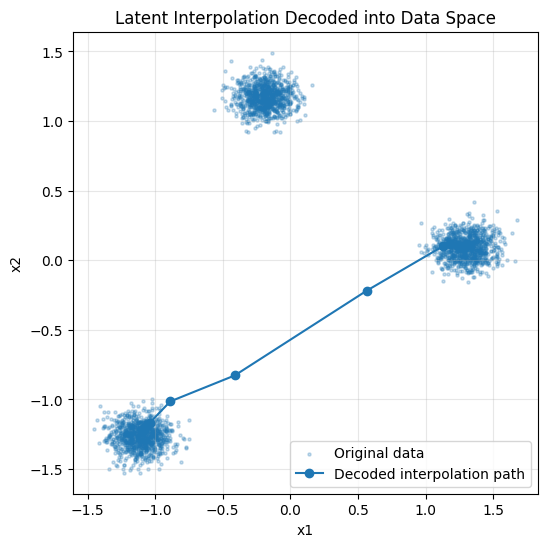

In [ ]:
plot_loss_history(mlp_history)
plot_original(X_data, title=f"Original {DATASET_KIND} Dataset")
plot_reconstructions(mlp_vae, X_data, n=1000)
plot_original_vs_reconstruction(mlp_vae, X_data, n=1000)
plot_latent_space(mlp_vae, X_data)
plot_generated(mlp_vae, n=1000, latent_dim=LATENT_DIM)
plot_interpolation(mlp_vae, X_data, idx1=0, idx2=100, steps=20)

## 11. How to Compare LinearVAE and MLPVAE

Do not judge only by final loss. Look at all plots.

### Reconstruction plot

If reconstructed points overlap the original shape, reconstruction works. If everything becomes one blob, the model may be underfitting or KL may be too strong.

### Latent space plot

If everything is a tiny dot, KL may be too strong. If points are extremely scattered, KL may be too weak.

### Generated samples plot

Good reconstruction but bad generation means the latent space is not smooth enough. Bad reconstruction and bad generation means the model or training setup is weak.

Expected for moons: `LinearVAE` may create a blurry cloud. `MLPVAE` should usually capture the curved structure better.

## 12. Alternatives Considered and Rejected

### Very deep network

Rejected because this is only 2D data. It adds complexity without clear benefit.

### `latent_dim = 10` as default

Rejected because the input is only 2D and a 10D latent space is harder to visualize. It is a good bonus experiment, not the default.

### Sigmoid hidden activation

Rejected because sigmoid can saturate and cause small gradients.

### `beta = 0` as the main result

Rejected because it removes the VAE regularization and becomes closer to a normal autoencoder.

### Using only final loss

Rejected because generative models must be checked visually. Loss alone can be misleading.

### Training only on moons

Rejected for debugging. Blobs are easier to verify first.

## 13. Bonus Experiments

Try these changes:

```python
DATASET_KIND = "blobs"
DATASET_KIND = "circles"
DATASET_KIND = "moons"
```

```python
activation = "relu"
activation = "leakyrelu"
activation = "tanh"
activation = "none"
```

```python
hidden_dims = []
hidden_dims = [16]
hidden_dims = [32, 32]
hidden_dims = [64, 64]
```

```python
BETA = 0.0
BETA = 0.1
BETA = 0.5
BETA = 1.0
BETA = 5.0
```

Expected: smaller beta improves reconstruction but weakens generation. Larger beta smooths latent space but can hurt reconstruction.

# Bonus Experiment: Effect of Latent Dimension

In a Variational Autoencoder (VAE), the latent dimension determines how much information the model can compress into its latent representation.

A very small latent dimension forces the model to learn only the most important features of the data, which may lead to information loss and poorer reconstructions. A larger latent dimension gives the model more capacity to represent the data, often improving reconstruction quality, but may also reduce the regularizing effect of the latent space.

In this experiment, we train the same Linear VAE using different latent dimensions:

- `latent_dim = 1`
- `latent_dim = 3`
- `latent_dim = 5`
- `latent_dim = 10`

For each setting, we observe:

1. Training loss behaviour.
2. Reconstruction quality.
3. Structure of the learned latent space.
4. Quality of generated samples.

The goal is to understand the trade-off between compression and representation capacity in a Variational Autoencoder.

Epoch   0 | Total: 2.4866 | Recon: 2.4356 | KL: 0.5097
Epoch 100 | Total: 0.7969 | Recon: 0.6431 | KL: 1.5374
Epoch 200 | Total: 0.7825 | Recon: 0.6182 | KL: 1.6427
Epoch 299 | Total: 0.7853 | Recon: 0.6174 | KL: 1.6794


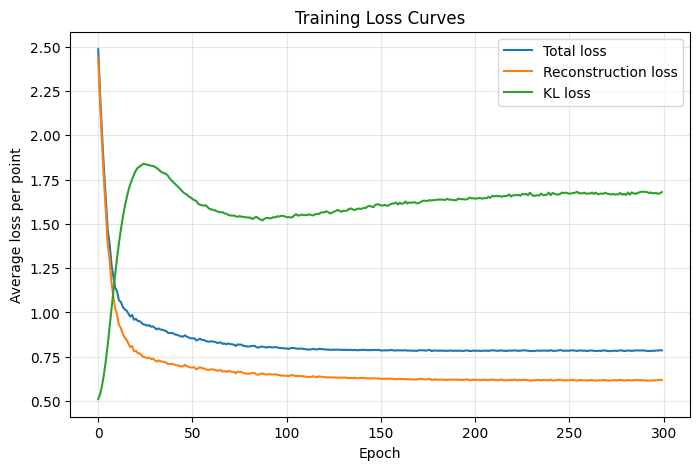

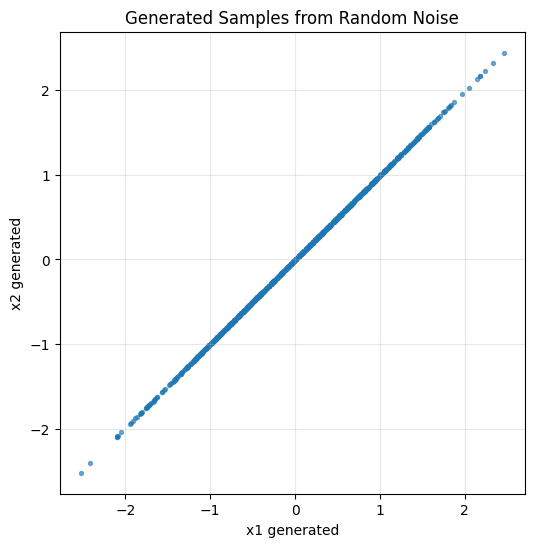

Epoch   0 | Total: 2.7456 | Recon: 2.6374 | KL: 1.0817
Epoch 100 | Total: 0.4073 | Recon: 0.1324 | KL: 2.7491
Epoch 200 | Total: 0.3911 | Recon: 0.1022 | KL: 2.8890
Epoch 299 | Total: 0.3879 | Recon: 0.0989 | KL: 2.8907


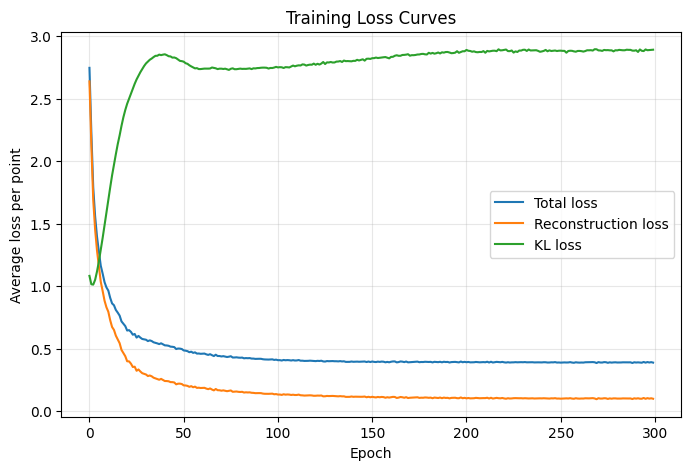

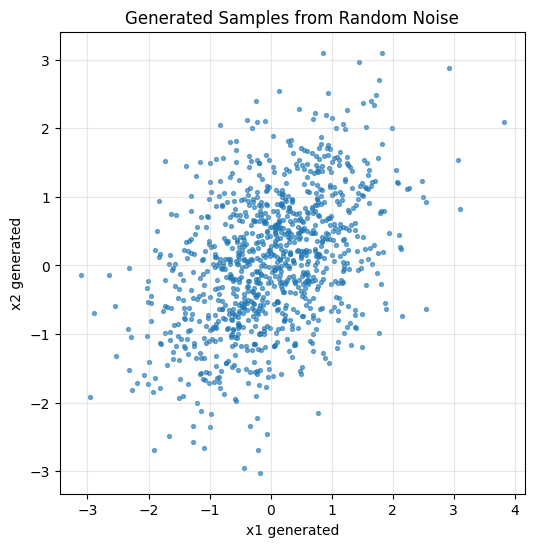

Epoch   0 | Total: 2.3552 | Recon: 2.1013 | KL: 2.5393
Epoch 100 | Total: 0.3917 | Recon: 0.1041 | KL: 2.8760
Epoch 200 | Total: 0.3877 | Recon: 0.0994 | KL: 2.8831
Epoch 299 | Total: 0.3907 | Recon: 0.1042 | KL: 2.8651


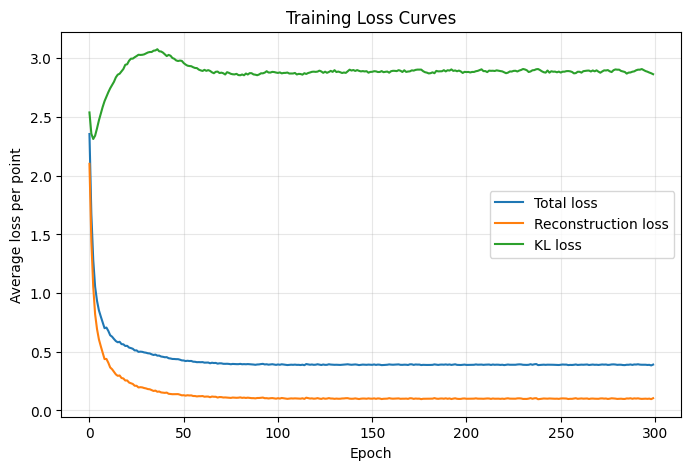

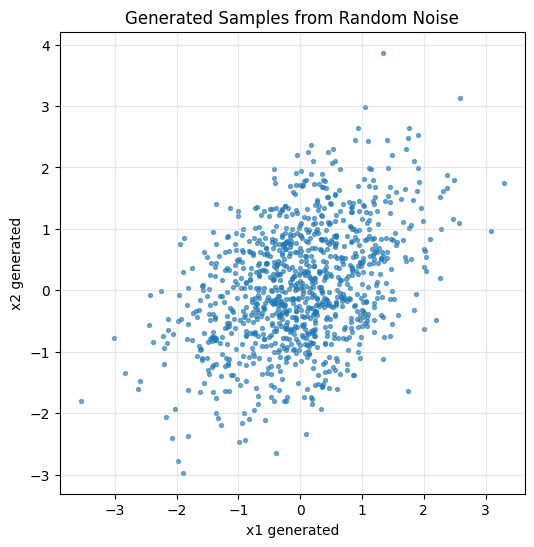

Epoch   0 | Total: 1.5878 | Recon: 1.2266 | KL: 3.6123
Epoch 100 | Total: 0.3923 | Recon: 0.1058 | KL: 2.8650
Epoch 200 | Total: 0.3916 | Recon: 0.1022 | KL: 2.8936
Epoch 299 | Total: 0.3892 | Recon: 0.0991 | KL: 2.9011


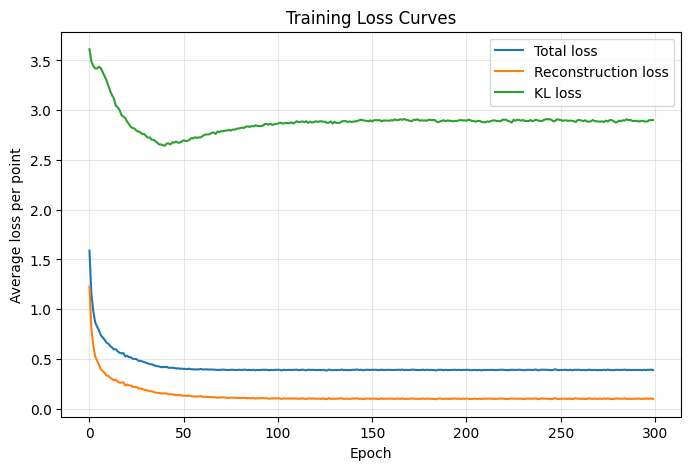

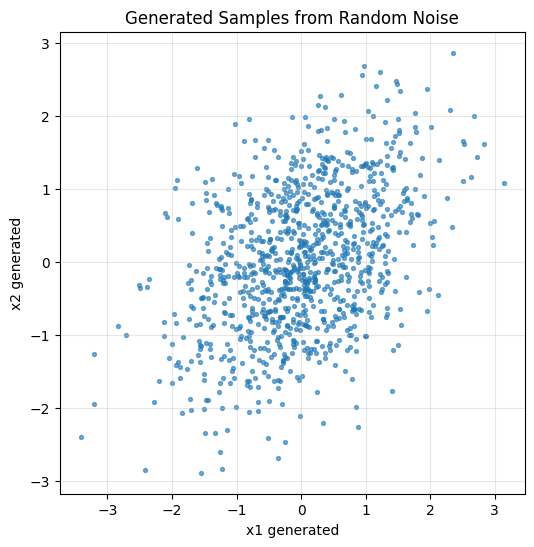

In [ ]:
for latent_dim in [1, 3, 5, 10]:
    model = LinearVAE(input_dim=2, latent_dim=latent_dim)
    history = train_vae(model, train_loader, epochs=300, lr=LR, beta=BETA, print_every=100)
    plot_loss_history(history)
    plot_generated(model, n=1000, latent_dim=latent_dim)

## 14. Final Summary

Main engineering decisions:

1. Start with 2D synthetic data because it is visual and easy to debug.
2. Start with `LinearVAE` because it is the assignment baseline.
3. Use `MLPVAE` with `[32, 32]` hidden layers for non-linear datasets like moons.
4. Use ReLU first; try LeakyReLU if needed.
5. Avoid sigmoid in hidden layers.
6. Keep `latent_dim = 2` because it is easy to visualize.
7. Use beta around `0.1` to `0.5` if KL dominates.
8. Evaluate using plots, not only loss.
9. Reject overly deep networks because this is a small 2D problem.
